Since the dataset is now organized by label folders (Bitumin, Block, Concrete, Kankar) and each folder contains chunked CSVs, you're set for training a deep learning model. Let’s go step-by-step for building the model from this structure.

## Step 1: Load and Prepare the Data

In [31]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization
import tensorflow as tf

# Harshit_Preprocessed_Data-CS250U

In [32]:
# Define base directory
base_dir = "Dataset/Harshit_Preprocessed_Data-CS250"

# Map folder names to class labels
label_map = {
    "Bitumin": 0,
    "Block": 1,
    "Concrete": 2,
    "Kanker": 3
}

X = []
y = []

In [33]:
# Iterate through each folder
for label_name, label in label_map.items():
    folder_path = os.path.join(base_dir, label_name)
    for file_name in os.listdir(folder_path):
        if file_name.endswith(".csv"):
            file_path = os.path.join(folder_path, file_name)
            try:
                df = pd.read_csv(file_path)
                # Ensure it has 200 rows and required columns
                if df.shape[0] == 250:
                    sample = df[['X_Acc', 'Y_Acc', 'Z_Acc', 'X_Gyro', 'Y_Gyro', 'Z_Gyro']].values
                    X.append(sample)
                    y.append(label)
            except Exception as e:
                print(f"Error reading {file_path}: {e}")

X = np.array(X)  # Shape: (samples, 200, 6)
y = np.array(y)

print("Loaded data shape:", X.shape, y.shape)


Loaded data shape: (1114, 250, 6) (1114,)


In [34]:
# --------------------- Class Weights ---------------------

class_labels = np.unique(y)
weights = compute_class_weight(class_weight='balanced', classes=class_labels, y=y)
class_weights = dict(zip(class_labels, weights))


In [35]:
# --------------------- Train-Test Split ---------------------

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [36]:
# --------------------- Focal Loss Function ---------------------

def focal_loss(gamma=2., alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=4)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weights = alpha * tf.math.pow(1 - y_pred, gamma)
        loss = weights * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))
    return focal_loss_fixed


In [37]:
# --------------------- Model Architecture ---------------------

model = Sequential([
    Bidirectional(LSTM(128, return_sequences=True), input_shape=(250, 6)),
    BatchNormalization(),
    Dropout(0.4),

    Bidirectional(LSTM(64)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss=focal_loss(gamma=2., alpha=0.25),
    metrics=['accuracy']
)


c:\Python312\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [38]:
# --------------------- Train Model ---------------------

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
)

Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 38s 516ms/step - accuracy: 0.2550 - loss: 0.3789 - val_accuracy: 0.4350 - val_loss: 0.1702
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 432ms/step - accuracy: 0.4628 - loss: 0.2324 - val_accuracy: 0.4843 - val_loss: 0.1562
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 419ms/step - accuracy: 0.5169 - loss: 0.1905 - val_accuracy: 0.5561 - val_loss: 0.1385
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 514ms/step - accuracy: 0.5698 - loss: 0.1512 - val_accuracy: 0.6009 - val_loss: 0.1247
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 451ms/step - accuracy: 0.5914 - loss: 0.1302 - val_accuracy: 0.5874 - val_loss: 0.1185
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 357ms/step - accuracy: 0.5987 - loss: 0.1332 - val_accuracy: 0.6323 - val_loss: 0.1113
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 442ms/step - accuracy: 0.6517 - loss: 0.1148 - val_accuracy: 0.6816 - val_loss: 0.1020
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 528ms/step - accuracy: 0.6627 - loss: 0.1108 - val_accu

---

## Step 5: Evaluate and Visualize Performance

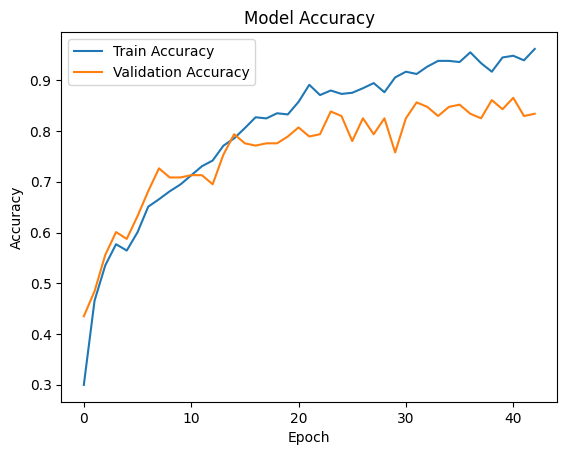

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.8316 - loss: 0.0830
Test Accuracy: 0.85


In [39]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Evaluate
loss, accuracy = model.evaluate(X_val, y_val)
print(f"Test Accuracy: {accuracy:.2f}")

## Confusion Matrix

35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step
              precision    recall  f1-score   support

     Bitumin       0.97      0.97      0.97       399
       Block       0.96      0.91      0.93       297
    Concrete       0.90      0.97      0.93       220
      Kanker       0.99      0.96      0.98       198

    accuracy                           0.95      1114
   macro avg       0.95      0.95      0.95      1114
weighted avg       0.96      0.95      0.95      1114



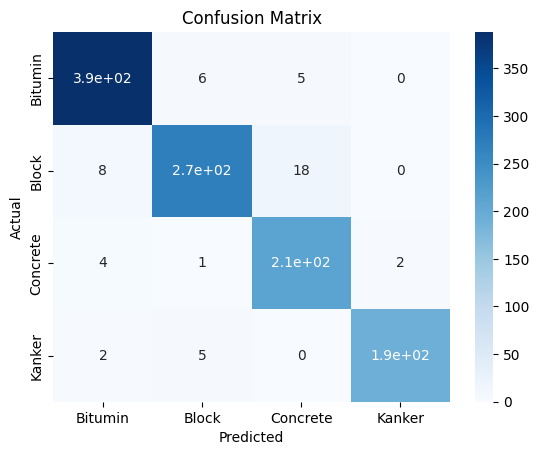

In [40]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict
y_pred = np.argmax(model.predict(X), axis=1)

# Evaluation
print(classification_report(y, y_pred, target_names=label_map.keys()))

# Confusion Matrix
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step


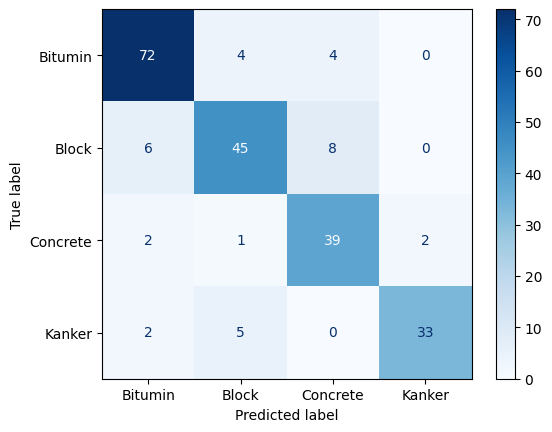

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_val, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_map.keys())
disp.plot(cmap='Blues')
plt.show()


## Save the Trained Model

In [42]:
model.save("Models/Model_Architecture(CS250-U)CB.h5")

## Full Real-Time Sample Inference Code:

#### Step 1: Load the Required Libraries

In [43]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler
import pandas as pd
import os

#### Step 2: Load the Trained Model

In [50]:
# If you used focal loss, redefine it before loading
def focal_loss(gamma=2., alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        loss = weight * cross_entropy
        return tf.reduce_sum(loss, axis=1)
    return focal_loss_fixed

# Load model
model = load_model('Models/Model_Architecture(CS250-U)CB.h5', custom_objects={'focal_loss_fixed': focal_loss()})


#### Step 3: Load and Prepare Real-Time or Test Data

In [51]:
# Example: Path to one of your 200-row test CSVs
test_file_path = r"Dataset\Harshit_Preprocessed_Data-CS250\Block\001_Abj_Block_10_12-2_part_001.csv"  # replace with your actual path

# Load CSV
df_test = pd.read_csv(test_file_path)

# Extract only numeric columns (assumes sensor data are only numeric)
X_test = df_test[['X_Acc', 'Y_Acc', 'Z_Acc', 'X_Gyro', 'Y_Gyro', 'Z_Gyro']].values

# Standardize using same scaler used during training (Assuming fit on full training set)
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)

# Reshape for LSTM [samples, time_steps, features]
X_test_scaled = X_test_scaled.reshape(1, X_test_scaled.shape[0], X_test_scaled.shape[1])


#### Step 4: Make Prediction

In [52]:
# Make prediction
pred_probs = model.predict(X_test_scaled)
pred_class = np.argmax(pred_probs)

# Mapping label index to actual class names
label_map = {0: 'Bitumin', 1: 'Block', 2: 'Concrete', 3: 'Kankar'}
print("Predicted Road Type:", label_map[pred_class])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step
Predicted Road Type: Kankar


----

# Load TFLite Model (for mobile testing)

In [ ]:
# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open("road_type_classifier.tflite", "wb") as f:
    f.write(tflite_model)

print("Model and TFLite version saved successfully.")


In [ ]:
# Load the TFLite model
interpreter = tf.lite.Interpreter(model_path="road_classifier_model.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Prepare input
input_data = X_test_scaled.astype(np.float32)

# Run inference
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()

# Get prediction
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_class = np.argmax(output_data)
print("TFLite Predicted Road Type:", label_map[predicted_class])
